# 03 — Exploratory Data Analysis & Insights: Online Retail II

Notebook ini melakukan EDA pada dataset **clean positive sales** hasil `02_data_cleaning.ipynb`.

### Pertanyaan analisis
1. Bagaimana tren revenue dari waktu ke waktu?
2. Negara mana yang memberikan revenue terbesar?
3. Produk apa yang paling berkontribusi terhadap revenue dan quantity?
4. Kapan transaksi paling aktif terjadi?
5. Seberapa terkonsentrasi revenue pada customer tertentu?
6. Insight bisnis apa yang dapat ditarik dari data?

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

%matplotlib inline

## 1. Menentukan project root dan load clean dataset

In [4]:
def find_project_root():
    candidates = [
        Path.cwd(),
        *Path.cwd().parents,
        Path("/home/jovyan/work"),
    ]

    # Hilangkan path duplikat
    candidates = list(dict.fromkeys(candidates))

    for base in candidates:
        if not base.exists():
            continue

        processed_dir = base / "data" / "processed"

        parquet_file = processed_dir / "online_retail_clean.parquet"
        csv_file = processed_dir / "online_retail_clean.csv"

        if parquet_file.exists() or csv_file.exists():
            return base.resolve()

    raise FileNotFoundError(
        "Dataset hasil cleaning tidak ditemukan. "
        "Jalankan 02_data_cleaning.ipynb terlebih dahulu."
    )


ROOT = find_project_root()

PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "eda"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

parquet_file = PROCESSED_DIR / "online_retail_clean.parquet"
csv_file = PROCESSED_DIR / "online_retail_clean.csv"


# ==========================================================
# Load dataset
# ==========================================================

if parquet_file.exists():

    print("Membaca Parquet...")
    df = pd.read_parquet(parquet_file)

elif csv_file.exists():

    print("Membaca CSV...")
    df = pd.read_csv(
        csv_file,
        low_memory=False
    )

else:

    raise FileNotFoundError(
        f"Tidak ditemukan:\\n"
        f"{parquet_file}\\n"
        f"atau\\n"
        f"{csv_file}"
    )


# Pastikan datetime benar
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    errors="coerce"
)


print("✅ Dataset berhasil dimuat")
print("Project root :", ROOT)
print("Dataset      :", parquet_file if parquet_file.exists() else csv_file)
print(f"Jumlah baris : {len(df):,}")
print(f"Jumlah kolom : {df.shape[1]:,}")

display(df.head())

Membaca Parquet...
✅ Dataset berhasil dimuat
Project root : /home/jovyan/work
Dataset      : /home/jovyan/work/data/processed/online_retail_clean.parquet
Jumlah baris : 1,029,609
Jumlah kolom : 17


,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_year,is_cancelled,revenue,date,year,month,month_num,day_name,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,False,83.40,2009-12-01,2009,2009-12,12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,81.00,2009-12-01,2009,2009-12,12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,81.00,2009-12-01,2009,2009-12,12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,False,100.80,2009-12-01,2009,2009-12,12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,False,30.00,2009-12-01,2009,2009-12,12,Tuesday,7


## 2. KPI utama

In [5]:
invoice_summary = (
    df.groupby("invoice", as_index=False)
      .agg(
          order_revenue=("revenue", "sum"),
          units=("quantity", "sum"),
          invoice_date=("invoice_date", "min"),
          country=("country", "first"),
          customer_id=("customer_id", "first"),
      )
)

kpis = pd.DataFrame({
    "KPI": [
        "Total revenue",
        "Total sales rows",
        "Unique invoices",
        "Unique products",
        "Unique customers (known ID)",
        "Countries",
        "Average order value",
        "Average units per invoice",
    ],
    "Value": [
        df["revenue"].sum(),
        len(df),
        df["invoice"].nunique(),
        df["stock_code"].nunique(),
        df["customer_id"].nunique(dropna=True),
        df["country"].nunique(),
        invoice_summary["order_revenue"].mean(),
        invoice_summary["units"].mean(),
    ]
})

display(kpis)

,KPI,Value
0,Total revenue,"20,913,891.47"
1,Total sales rows,"1,029,609.00"
2,Unique invoices,"40,077.00"
3,Unique products,"4,916.00"
4,Unique customers (known ID),"5,878.00"
5,Countries,43.00
6,Average order value,521.84
7,Average units per invoice,284.09


## 3. Tren revenue bulanan

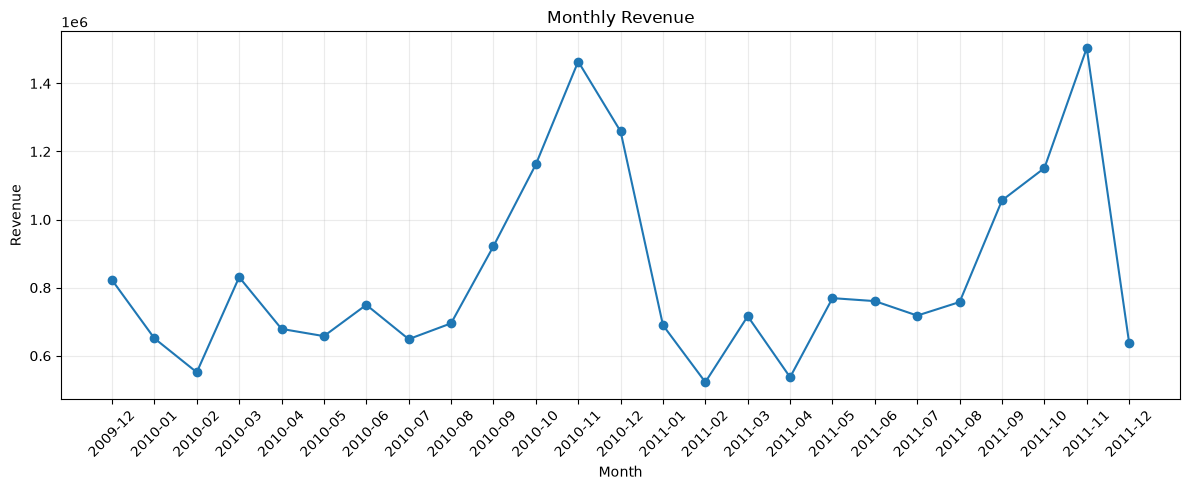

,month_period,revenue,invoices,units,month
0,2009-12,"822,483.95",1682,425461,2009-12
1,2010-01,"651,155.11",1105,390672,2010-01
2,2010-02,"551,504.73",1201,381879,2010-02
3,2010-03,"830,915.26",1681,526026,2010-03
4,2010-04,"678,875.25",1462,366705,2010-04
5,2010-05,"657,705.50",1500,395868,2010-05
6,2010-06,"749,537.31",1645,406820,2010-06
7,2010-07,"648,810.27",1529,337895,2010-07
8,2010-08,"695,251.91",1425,472380,2010-08
9,2010-09,"921,696.99",1839,583864,2010-09


In [6]:
monthly = (
    df.assign(month_period=df["invoice_date"].dt.to_period("M"))
      .groupby("month_period", as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          invoices=("invoice", "nunique"),
          units=("quantity", "sum"),
      )
)

monthly["month"] = monthly["month_period"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["month"], monthly["revenue"], marker="o")
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

display(monthly)

## 4. Revenue berdasarkan negara

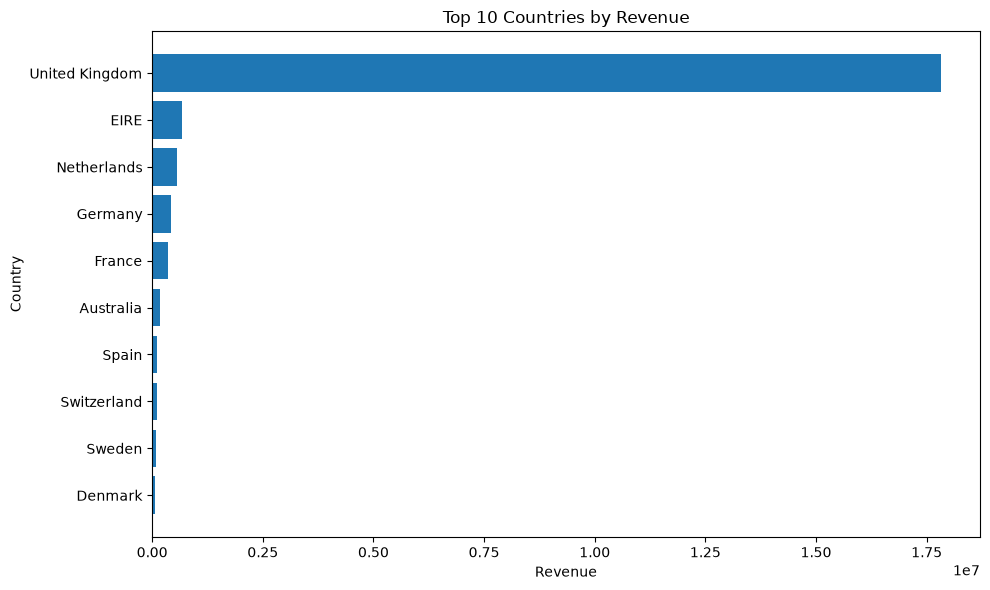

,country,revenue,invoices,units
40,United Kingdom,"17,814,055.93",36535,9349186
11,EIRE,"664,050.09",626,340054
26,Netherlands,"554,230.69",228,383976
15,Germany,"430,703.79",789,227769
14,France,"356,746.51",622,275090
0,Australia,"169,900.61",95,104080
34,Spain,"109,127.21",154,50774
36,Switzerland,"100,988.99",93,52872
35,Sweden,"91,869.82",105,88633
10,Denmark,"69,862.19",43,237925


In [7]:
country_revenue = (
    df.groupby("country", as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          invoices=("invoice", "nunique"),
          units=("quantity", "sum"),
      )
      .sort_values("revenue", ascending=False)
)

top_country = country_revenue.head(10).sort_values("revenue")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_country["country"], top_country["revenue"])
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Country")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_top_countries_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

display(country_revenue.head(15))

### Negara di luar United Kingdom

Karena dataset sangat didominasi UK, tabel berikut membantu melihat pasar internasional tanpa efek dominasi UK.

In [8]:
non_uk = country_revenue[
    country_revenue["country"].str.lower().ne("united kingdom")
].head(15)

display(non_uk)

,country,revenue,invoices,units
11,EIRE,"664,050.09",626,340054
26,Netherlands,"554,230.69",228,383976
15,Germany,"430,703.79",789,227769
14,France,"356,746.51",622,275090
0,Australia,"169,900.61",95,104080
34,Spain,"109,127.21",154,50774
36,Switzerland,"100,988.99",93,52872
35,Sweden,"91,869.82",105,88633
10,Denmark,"69,862.19",43,237925
3,Belgium,"65,733.92",149,35296


## 5. Produk dengan revenue terbesar

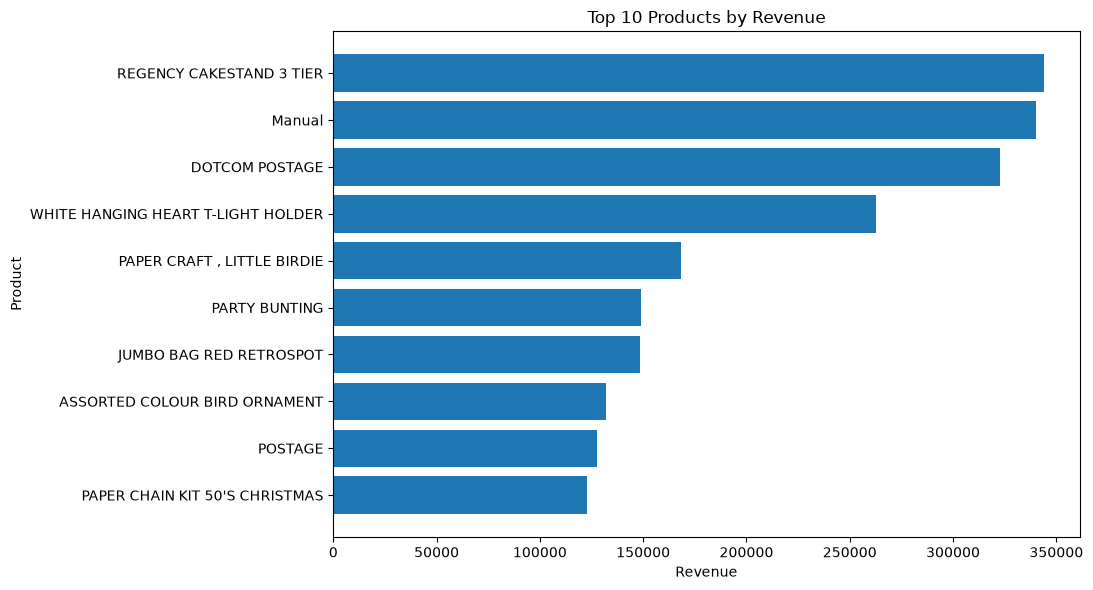

,stock_code,description,revenue,units,invoices
1875,22423,REGENCY CAKESTAND 3 TIER,"344,069.30",27536,3918
5585,M,Manual,"340,327.63",9748,784
5584,DOT,DOTCOM POSTAGE,"322,657.48",1436,1415
4970,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"262,589.96",95966,5356
3335,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
3694,47566,PARTY BUNTING,"149,109.35",28362,2674
4939,85099B,JUMBO BAG RED RETROSPOT,"148,528.63",78698,3245
4612,84879,ASSORTED COLOUR BIRD ORNAMENT,"131,817.81",81590,2807
5587,POST,POSTAGE,"127,597.42",5461,1851
1465,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"123,002.89",36534,2018


In [9]:
product_revenue = (
    df.groupby(["stock_code", "description"], as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          units=("quantity", "sum"),
          invoices=("invoice", "nunique"),
      )
      .sort_values("revenue", ascending=False)
)

top_products_rev = product_revenue.head(10).sort_values("revenue")

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products_rev["description"], top_products_rev["revenue"])
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Product")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_top_products_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

display(product_revenue.head(15))

## 6. Produk dengan quantity terbesar

In [10]:
product_units = (
    df.groupby(["stock_code", "description"], as_index=False)
      .agg(
          units=("quantity", "sum"),
          revenue=("revenue", "sum"),
      )
      .sort_values("units", ascending=False)
)

display(product_units.head(15))

,stock_code,description,units,revenue
4145,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,109898,"25,197.98"
4970,85123A,WHITE HANGING HEART T-LIGHT HOLDER,95966,"262,589.96"
4612,84879,ASSORTED COLOUR BIRD ORNAMENT,81590,"131,817.81"
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60"
4939,85099B,JUMBO BAG RED RETROSPOT,78698,"148,528.63"
2790,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92"
120,17003,BROCADE RING PURSE,71394,"14,948.75"
1374,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56625,"28,413.63"
4773,84991,60 TEATIME FAIRY CAKE CASES,54537,"27,321.37"
1593,22197,SMALL POPCORN HOLDER,49922,"44,068.03"


## 7. Pola transaksi berdasarkan hari

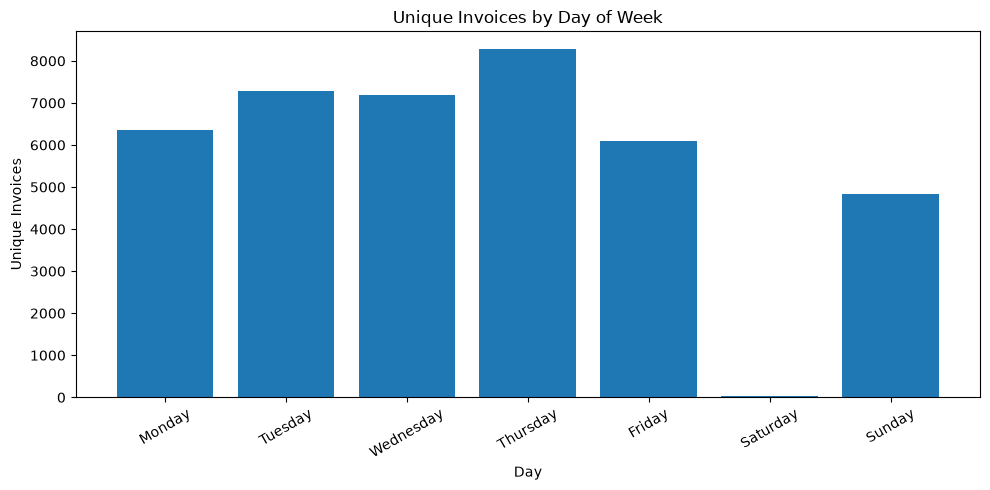

,day_name,revenue,invoices,units
1,Monday,"3,636,218.33",6351,2052462
5,Tuesday,"4,177,703.81",7291,2168140
6,Wednesday,"3,592,456.48",7185,2049625
4,Thursday,"4,296,390.37",8288,2371578
0,Friday,"3,370,807.51",6097,1694885
2,Saturday,"9,803.05",30,5119
3,Sunday,"1,830,511.91",4835,1043559


In [11]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

day_activity = (
    df.groupby("day_name", as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          invoices=("invoice", "nunique"),
          units=("quantity", "sum"),
      )
)

day_activity["day_name"] = pd.Categorical(
    day_activity["day_name"],
    categories=day_order,
    ordered=True
)
day_activity = day_activity.sort_values("day_name")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(day_activity["day_name"].astype(str), day_activity["invoices"])
ax.set_title("Unique Invoices by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Unique Invoices")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_invoices_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

display(day_activity)

## 8. Pola transaksi berdasarkan jam

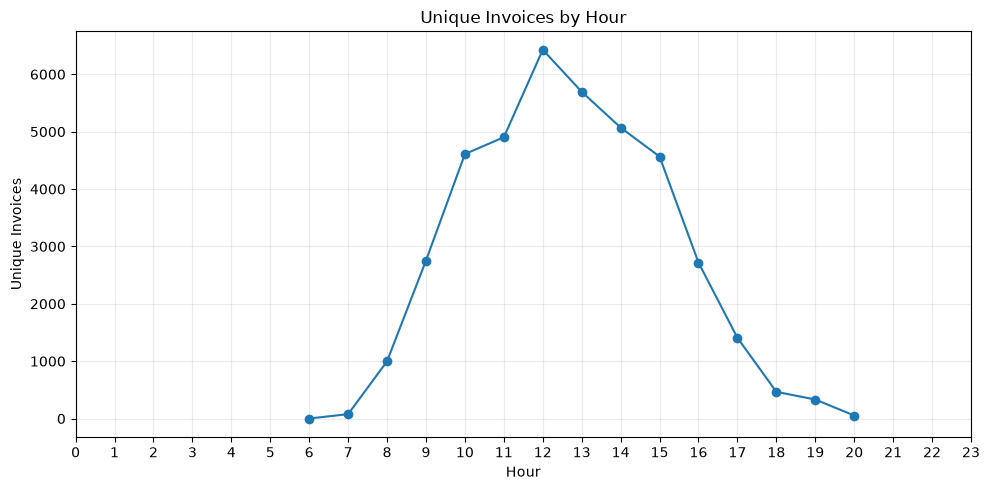

,hour,revenue,invoices,units
0,6,4.25,1,1
1,7,"76,232.57",77,45031
2,8,"532,317.54",998,297814
3,9,"1,801,862.65",2754,930437
4,10,"2,625,526.12",4610,1510819
5,11,"2,576,203.22",4903,1466307
6,12,"2,898,990.35",6427,1690992
7,13,"2,591,353.03",5695,1572424
8,14,"2,376,921.43",5071,1208832
9,15,"2,471,910.19",4566,1268397


In [12]:
hour_activity = (
    df.groupby("hour", as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          invoices=("invoice", "nunique"),
          units=("quantity", "sum"),
      )
      .sort_values("hour")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hour_activity["hour"], hour_activity["invoices"], marker="o")
ax.set_title("Unique Invoices by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Unique Invoices")
ax.set_xticks(range(0, 24))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_invoices_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

display(hour_activity)

## 9. Analisis customer

Analisis customer hanya menggunakan baris yang mempunyai `customer_id`.

In [13]:
customer_df = df[df["customer_id"].notna()].copy()

customer_summary = (
    customer_df.groupby("customer_id", as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          invoices=("invoice", "nunique"),
          units=("quantity", "sum"),
          first_purchase=("invoice_date", "min"),
          last_purchase=("invoice_date", "max"),
      )
      .sort_values("revenue", ascending=False)
)

customer_summary["revenue_share_pct"] = (
    customer_summary["revenue"] / customer_summary["revenue"].sum() * 100
)

customer_summary["cumulative_revenue_share_pct"] = (
    customer_summary["revenue_share_pct"].cumsum()
)

display(customer_summary.head(15))

,customer_id,revenue,invoices,units,first_purchase,last_purchase,revenue_share_pct,cumulative_revenue_share_pct
5692,18102,"608,821.65",145,188340,2009-12-01 09:24:00,2011-12-09 11:50:00,3.44,3.44
2277,14646,"528,602.52",151,367193,2009-12-02 16:52:00,2011-12-08 12:12:00,2.99,6.43
1789,14156,"313,759.82",156,165873,2009-12-01 12:30:00,2011-11-30 10:54:00,1.77,8.21
2538,14911,"295,832.39",398,149949,2009-12-01 11:41:00,2011-12-08 15:54:00,1.67,9.88
5050,17450,"246,813.09",51,84700,2010-09-27 16:59:00,2011-12-01 13:29:00,1.40,11.27
1331,13694,"196,482.81",143,189205,2009-12-04 15:26:00,2011-12-06 09:32:00,1.11,12.38
5109,17511,"175,603.55",60,119656,2009-12-02 10:52:00,2011-12-07 10:12:00,0.99,13.38
4061,16446,"168,472.50",2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,0.95,14.33
4295,16684,"147,142.77",55,104810,2009-12-07 12:56:00,2011-12-05 14:06:00,0.83,15.16
68,12415,"144,458.37",28,91447,2010-06-30 08:30:00,2011-11-15 14:22:00,0.82,15.98


## 10. Konsentrasi revenue customer

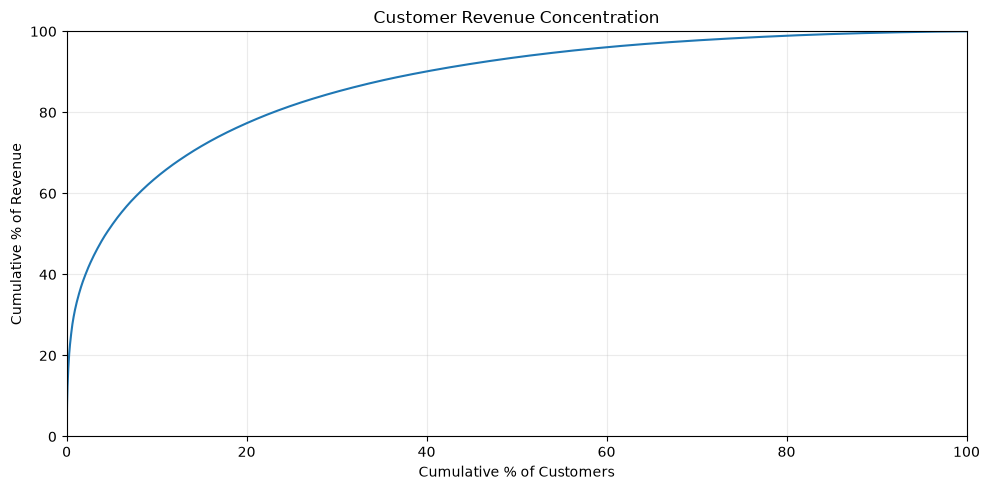

In [14]:
customer_sorted = customer_summary.reset_index(drop=True).copy()
customer_sorted["customer_rank_pct"] = (
    (customer_sorted.index + 1) / len(customer_sorted) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    customer_sorted["customer_rank_pct"],
    customer_sorted["cumulative_revenue_share_pct"]
)
ax.set_title("Customer Revenue Concentration")
ax.set_xlabel("Cumulative % of Customers")
ax.set_ylabel("Cumulative % of Revenue")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_customer_revenue_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. RFM-style customer summary

RFM:
- **Recency** = berapa hari sejak pembelian terakhir sampai akhir periode data.
- **Frequency** = jumlah invoice unik.
- **Monetary** = total revenue customer.

Bagian ini belum melakukan clustering; tujuannya membuat dasar segmentasi customer.

In [15]:
snapshot_date = df["invoice_date"].max().normalize() + pd.Timedelta(days=1)

rfm = (
    customer_df.groupby("customer_id")
      .agg(
          last_purchase=("invoice_date", "max"),
          frequency=("invoice", "nunique"),
          monetary=("revenue", "sum"),
      )
      .reset_index()
)

rfm["recency_days"] = (
    snapshot_date - rfm["last_purchase"].dt.normalize()
).dt.days

rfm = rfm[
    ["customer_id", "recency_days", "frequency", "monetary", "last_purchase"]
].sort_values("monetary", ascending=False)

display(rfm.head(15))

,customer_id,recency_days,frequency,monetary,last_purchase
5692,18102,1,145,"608,821.65",2011-12-09 11:50:00
2277,14646,2,151,"528,602.52",2011-12-08 12:12:00
1789,14156,10,156,"313,759.82",2011-11-30 10:54:00
2538,14911,2,398,"295,832.39",2011-12-08 15:54:00
5050,17450,9,51,"246,813.09",2011-12-01 13:29:00
1331,13694,4,143,"196,482.81",2011-12-06 09:32:00
5109,17511,3,60,"175,603.55",2011-12-07 10:12:00
4061,16446,1,2,"168,472.50",2011-12-09 09:15:00
4295,16684,5,55,"147,142.77",2011-12-05 14:06:00
68,12415,25,28,"144,458.37",2011-11-15 14:22:00


## 12. Insight otomatis dari hasil EDA

Cell berikut menghasilkan beberapa insight berdasarkan hasil aktual dataset, sehingga tidak bergantung pada angka yang ditulis manual.

In [16]:
peak_month = monthly.loc[monthly["revenue"].idxmax()]
top_country_row = country_revenue.iloc[0]
top_product_row = product_revenue.iloc[0]
peak_day = day_activity.loc[day_activity["invoices"].idxmax()]
peak_hour = hour_activity.loc[hour_activity["invoices"].idxmax()]

total_customer_revenue = customer_summary["revenue"].sum()
top_10_customer_share = (
    customer_summary.head(10)["revenue"].sum() / total_customer_revenue * 100
)

top_country_share = top_country_row["revenue"] / df["revenue"].sum() * 100

print("INSIGHT UTAMA")
print("=" * 70)
print(
    f"1. Bulan dengan revenue tertinggi adalah {peak_month['month']} "
    f"dengan revenue {peak_month['revenue']:,.2f}."
)
print(
    f"2. Negara dengan revenue tertinggi adalah {top_country_row['country']} "
    f"dengan kontribusi sekitar {top_country_share:.2f}% dari total revenue."
)
print(
    f"3. Produk dengan revenue tertinggi adalah "
    f"{top_product_row['description']} "
    f"dengan revenue {top_product_row['revenue']:,.2f}."
)
print(
    f"4. Hari dengan jumlah invoice unik tertinggi adalah "
    f"{peak_day['day_name']} ({int(peak_day['invoices']):,} invoice)."
)
print(
    f"5. Jam transaksi paling aktif adalah sekitar pukul "
    f"{int(peak_hour['hour']):02d}:00 "
    f"({int(peak_hour['invoices']):,} invoice unik)."
)
print(
    f"6. Sepuluh customer dengan revenue terbesar menyumbang "
    f"{top_10_customer_share:.2f}% revenue dari customer yang teridentifikasi."
)

INSIGHT UTAMA
1. Bulan dengan revenue tertinggi adalah 2011-11 dengan revenue 1,503,866.78.
2. Negara dengan revenue tertinggi adalah United Kingdom dengan kontribusi sekitar 85.18% dari total revenue.
3. Produk dengan revenue tertinggi adalah REGENCY CAKESTAND 3 TIER dengan revenue 344,069.30.
4. Hari dengan jumlah invoice unik tertinggi adalah Thursday (8,288 invoice).
5. Jam transaksi paling aktif adalah sekitar pukul 12:00 (6,427 invoice unik).
6. Sepuluh customer dengan revenue terbesar menyumbang 15.98% revenue dari customer yang teridentifikasi.


## 13. Export tabel hasil EDA

In [17]:
monthly.drop(columns="month_period").to_csv(
    EDA_DIR / "monthly_summary.csv",
    index=False
)

country_revenue.to_csv(
    EDA_DIR / "country_revenue.csv",
    index=False
)

product_revenue.to_csv(
    EDA_DIR / "product_revenue.csv",
    index=False
)

customer_summary.to_csv(
    EDA_DIR / "customer_summary.csv",
    index=False
)

rfm.to_csv(
    EDA_DIR / "rfm_summary.csv",
    index=False
)

print("Output EDA tersimpan di:", EDA_DIR)
print("Figures tersimpan di   :", FIG_DIR)

NameError: name 'EDA_DIR' is not defined

## 14. Kesimpulan

Struktur narasi yang dapat dipakai pada laporan:

- Jelaskan **tren waktu** dan bulan dengan performa tertinggi.
- Jelaskan **dominasi negara utama** serta peluang dari pasar non-UK.
- Identifikasi **produk utama** berdasarkan revenue dan quantity.
- Jelaskan **pola hari dan jam transaksi** sebagai dasar keputusan operasional/promosi.
- Jelaskan **konsentrasi revenue customer** dan manfaat segmentasi berbasis RFM.
- Hindari menyimpulkan sebab-akibat hanya dari EDA; hasil di notebook ini menunjukkan pola dan asosiasi pada data transaksi.